# Benchmark policy rules: TR93, NPP, BA

Static prescriptions of the three benchmark rules against the effective federal funds rate, on the same FRED data as the linear-environment notebooks, fetched through `fedfred`.

**Rule form** (Hinterlang & Tänzer 2021, linear case; algebraically the Fed MPR form with $y_t = 2(u^* - u_t)$):

$$
i_t = \alpha_0 + \beta_\pi \pi_t + \beta_y y_t, \qquad \alpha_0 = r^* - (\beta_\pi - 1)\pi^*, \qquad r^* = \pi^* = 2
$$

| Rule | $\alpha_0$ | $\beta_\pi$ | $\beta_y$ | MPR form |
|---|---|---|---|---|
| TR93 | 1 | 1.5 | 0.5 | $r^* + \pi_t + 0.5(\pi_t - \pi^*) + 0.5\,y_t$ |
| NPP | 0 | 2.0 | 0.5 | $r^* + \pi_t + 1.0(\pi_t - \pi^*) + 0.5\,y_t$ |
| BA | 1 | 1.5 | 1.0 | $r^* + \pi_t + 0.5(\pi_t - \pi^*) + 1.0\,y_t$ |

**Data**

| Variable | Construction | FRED series |
|---|---|---|
| $\pi_t$ | GDP deflator inflation, percent | `GDPDEF` |
| $y_t$ | $100\,(\mathrm{GDPC1}_t / \mathrm{GDPPOT}_t - 1)$ | `GDPC1`, `GDPPOT` |
| $i_t$ | Effective federal funds rate, quarterly average | `FEDFUNDS` |

## 1. Configuration

In [3]:
# MIT License
# Copyright (c) 2026 Nikhil Sunder

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from fedfred import FredAPI

SAMPLE_START = "1987-07-01"   # 1987Q3
SAMPLE_END: str | None = None  # None -> latest available quarter
EST_START = "1987-07-01"      # estimation window shaded in the figures
EST_END = "2007-04-01"        # 2007Q2

INFLATION = "yoy"             # "yoy": 100*(P_t/P_{t-4} - 1); "qoq_ann": 400*ln(P_t/P_{t-1})
R_STAR = 2.0
PI_STAR = 2.0
ZLB = False                   # floor rule prescriptions at zero

FIG_DIR = Path("figs")
FIG_DPI = 200

if INFLATION not in {"yoy", "qoq_ann"}:
    raise ValueError(f"INFLATION must be 'yoy' or 'qoq_ann', got {INFLATION!r}")

## 2. Data

In [4]:
fred = FredAPI(api_key="7ab121fb17773e187bb6508e83e411da")

# Pull five extra quarters so the inflation transform is defined at SAMPLE_START.
_fetch_start = (pd.Timestamp(SAMPLE_START) - pd.DateOffset(months=15)).strftime("%Y-%m-%d")


def fetch_quarterly(series_id: str, **kwargs: str) -> pd.Series:
    """Fetch one FRED series as a float Series indexed by quarter-start Timestamp.

    Args:
        series_id: FRED series identifier.
        **kwargs: Extra ``get_series_observations`` arguments (e.g. ``frequency``).

    Returns:
        Series named ``series_id`` on a unique, sorted quarter-start index.

    Raises:
        KeyError: The response has no ``value`` column.
        ValueError: The response is empty or entirely missing.
    """
    obs = fred.get_series_observations(
        series_id,
        observation_start=_fetch_start,
        observation_end=SAMPLE_END,
        **kwargs,
    )
    if not isinstance(obs, pd.DataFrame):
        raise TypeError(f"{series_id}: expected pandas.DataFrame, got {type(obs).__name__}")
    if "value" not in obs.columns:
        raise KeyError(f"{series_id}: no 'value' column; have {list(obs.columns)}")
    index = pd.to_datetime(obs.index).to_period("Q").to_timestamp(how="start")
    s = pd.Series(pd.to_numeric(obs["value"], errors="coerce").to_numpy(), index=index, name=series_id)
    s = s[~s.index.duplicated(keep="last")].sort_index()
    if s.dropna().empty:
        raise ValueError(f"{series_id}: FRED returned no usable observations")
    return s


raw = pd.concat(
    [
        fetch_quarterly("GDPDEF"),
        fetch_quarterly("GDPC1"),
        fetch_quarterly("GDPPOT"),
        fetch_quarterly("FEDFUNDS", frequency="q", aggregation_method="avg"),
    ],
    axis=1,
)
raw.dropna().tail()

,GDPDEF,GDPC1,GDPPOT,FEDFUNDS
date,,,,
2025-04-01,128.243,23884.563,23548.517662,4.33
2025-07-01,129.310,24112.966,23680.152477,4.29
2025-10-01,130.412,24125.479,23811.223897,3.90
2026-01-01,131.440,24274.383,23945.137839,3.64
2026-04-01,133.411,24408.011,24070.938648,3.63


In [5]:
if INFLATION == "yoy":
    pi = 100.0 * (raw["GDPDEF"] / raw["GDPDEF"].shift(4) - 1.0)
else:
    pi = 400.0 * np.log(raw["GDPDEF"] / raw["GDPDEF"].shift(1))

df = pd.DataFrame(
    {
        "pi": pi,
        "y": 100.0 * (raw["GDPC1"] / raw["GDPPOT"] - 1.0),
        "ffr": raw["FEDFUNDS"],
    }
).dropna()  # also trims CBO projection quarters beyond the last GDPC1 release
df = df.loc[SAMPLE_START:SAMPLE_END]

if df.empty:
    raise ValueError("no overlapping quarters across GDPDEF, GDPC1, GDPPOT, FEDFUNDS")
if df.index[0] != pd.Timestamp(SAMPLE_START):
    raise ValueError(f"sample starts at {df.index[0].date()}, expected {SAMPLE_START}")

print(f"{len(df)} quarters: {df.index[0].to_period('Q')} to {df.index[-1].to_period('Q')}")
df.describe().loc[["mean", "std", "min", "max"]].round(2)

156 quarters: 1987Q3 to 2026Q2


,pi,y,ffr
mean,2.39,-0.32,3.22
std,1.24,1.80,2.61
min,0.12,-8.83,0.06
max,7.77,2.48,9.73


## 3. Rules

In [6]:
@dataclass(frozen=True)
class RuleSpec:
    """Linear rule i_t = alpha_0 + beta_pi * pi_t + beta_y * y_t.

    Attributes:
        name: Label used in legends, tables and file names.
        beta_pi: Total response to inflation (not to the inflation gap).
        beta_y: Response to the output gap.
        color: Matplotlib color.
        r_star: Long-run real rate, percent.
        pi_star: Inflation target, percent.
    """

    name: str
    beta_pi: float
    beta_y: float
    color: str
    r_star: float = R_STAR
    pi_star: float = PI_STAR

    @property
    def alpha0(self) -> float:
        """Intercept implied by r*, pi* and beta_pi."""
        return self.r_star - (self.beta_pi - 1.0) * self.pi_star

    def prescribe(self, pi: pd.Series, y: pd.Series, zlb: bool = False) -> pd.Series:
        """Prescribed policy rate, optionally floored at zero."""
        rate = self.alpha0 + self.beta_pi * pi + self.beta_y * y
        return rate.clip(lower=0.0) if zlb else rate


RULES: tuple[RuleSpec, ...] = (
    RuleSpec("TR93", beta_pi=1.5, beta_y=0.5, color="#d62728"),
    RuleSpec("NPP", beta_pi=2.0, beta_y=0.5, color="#e6b800"),
    RuleSpec("BA", beta_pi=1.5, beta_y=1.0, color="#2ca02c"),
)

presc = pd.DataFrame({"actual": df["ffr"]})
for rule in RULES:
    presc[rule.name] = rule.prescribe(df["pi"], df["y"], zlb=ZLB)

pd.DataFrame(
    {"alpha_0": [r.alpha0 for r in RULES], "beta_pi": [r.beta_pi for r in RULES], "beta_y": [r.beta_y for r in RULES]},
    index=[r.name for r in RULES],
)

,alpha_0,beta_pi,beta_y
TR93,1.0,1.5,0.5
NPP,0.0,2.0,0.5
BA,1.0,1.5,1.0


## 4. Figures

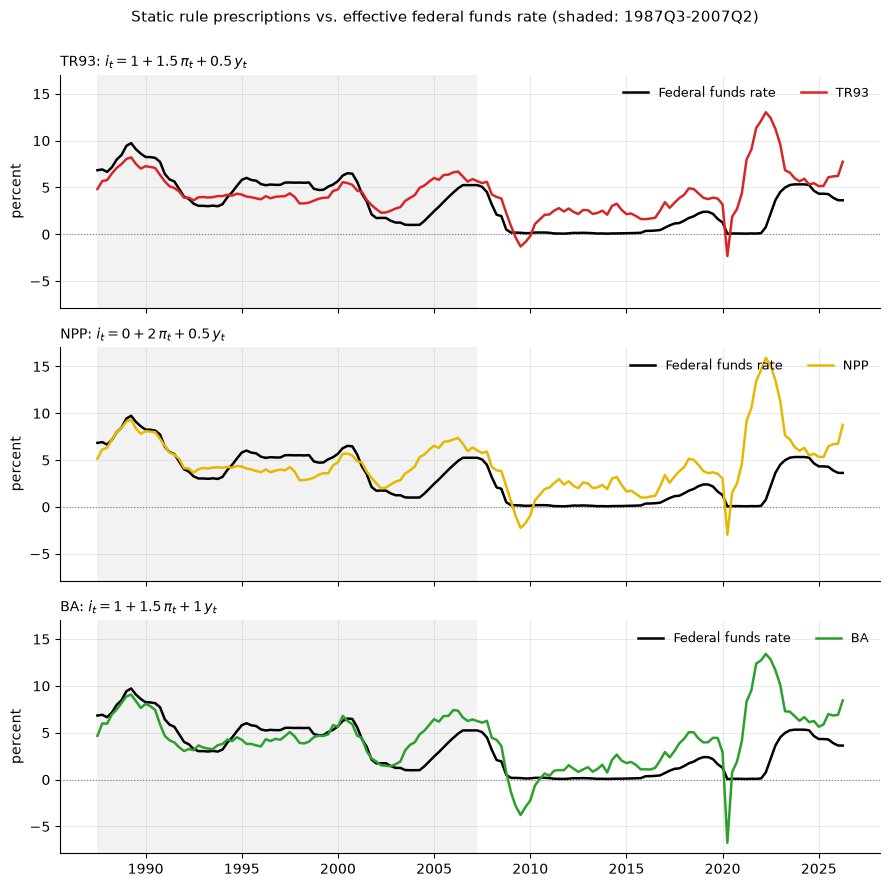

In [7]:
def draw_rule(ax: plt.Axes, rule: RuleSpec, legend: bool = True) -> None:
    """Draw one rule against the actual funds rate on ``ax``."""
    ax.axvspan(pd.Timestamp(EST_START), pd.Timestamp(EST_END), color="grey", alpha=0.10, lw=0)
    ax.axhline(0.0, color="grey", lw=0.8, ls=":")
    ax.plot(presc.index, presc["actual"], color="black", lw=1.8, label="Federal funds rate")
    ax.plot(presc.index, presc[rule.name], color=rule.color, lw=1.8, label=rule.name)
    ax.set_title(
        rf"{rule.name}: $i_t = {rule.alpha0:g} + {rule.beta_pi:g}\,\pi_t + {rule.beta_y:g}\,y_t$",
        loc="left", fontsize=10,
    )
    ax.set_ylabel("percent")
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)
    if legend:
        ax.legend(frameon=False, loc="upper right", ncol=2, fontsize=9)


FIG_DIR.mkdir(parents=True, exist_ok=True)

# One standalone file per rule
for rule in RULES:
    fig, ax = plt.subplots(figsize=(9, 3.6))
    draw_rule(ax, rule)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"rule_{rule.name.lower()}.png", dpi=FIG_DPI)
    plt.close(fig)

# Three-panel version
fig, axes = plt.subplots(len(RULES), 1, figsize=(9, 9), sharex=True, sharey=True)
for ax, rule in zip(axes, RULES):
    draw_rule(ax, rule)
fig.suptitle("Static rule prescriptions vs. effective federal funds rate (shaded: 1987Q3-2007Q2)", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.98))
fig.savefig(FIG_DIR / "rules_panels.png", dpi=FIG_DPI)
plt.show()

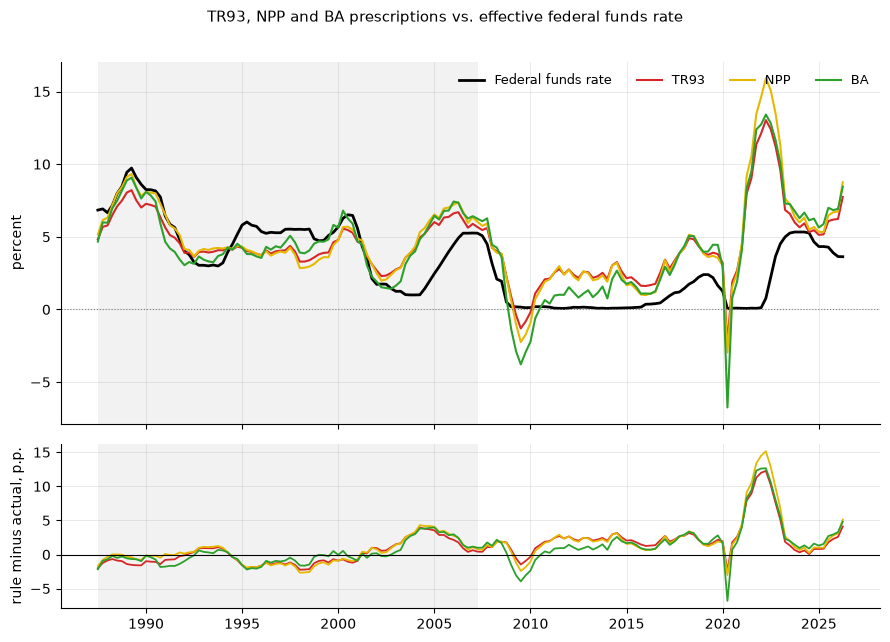

In [8]:
fig, (ax_lvl, ax_dev) = plt.subplots(
    2, 1, figsize=(9, 6.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]}
)
ax_lvl.plot(presc.index, presc["actual"], color="black", lw=2.0, label="Federal funds rate")
for rule in RULES:
    ax_lvl.plot(presc.index, presc[rule.name], color=rule.color, lw=1.5, label=rule.name)
    ax_dev.plot(presc.index, presc[rule.name] - presc["actual"], color=rule.color, lw=1.3)

ax_lvl.axhline(0.0, color="grey", lw=0.8, ls=":")
ax_dev.axhline(0.0, color="black", lw=0.8)
ax_lvl.set_ylabel("percent")
ax_dev.set_ylabel("rule minus actual, p.p.")
ax_lvl.legend(frameon=False, ncol=4, loc="upper right", fontsize=9)
for ax in (ax_lvl, ax_dev):
    ax.axvspan(pd.Timestamp(EST_START), pd.Timestamp(EST_END), color="grey", alpha=0.10, lw=0)
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("TR93, NPP and BA prescriptions vs. effective federal funds rate", fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(FIG_DIR / "rules_combined.png", dpi=FIG_DPI)
plt.show()

## 5. Deviations from the actual funds rate

In [9]:
names = [r.name for r in RULES]
dev = presc[names].sub(presc["actual"], axis=0)
windows = {
    "1987Q3-2007Q2": dev.loc[EST_START:EST_END],
    "full sample": dev,
}
summary = pd.concat(
    {
        label: pd.DataFrame(
            {"mean dev": d.mean(), "mean abs dev": d.abs().mean(), "RMSE": np.sqrt((d**2).mean())}
        )
        for label, d in windows.items()
    },
    axis=1,
).round(2)

presc.round(4).to_csv(FIG_DIR / "rule_prescriptions.csv", index_label="date")
summary

1987Q3-2007Q2                    full sample                   
          mean dev mean abs dev  RMSE    mean dev mean abs dev  RMSE
TR93         -0.04         1.35  1.60        1.20         1.98  2.82
NPP           0.19         1.31  1.70        1.39         2.09  3.26
BA            0.05         1.15  1.55        1.04         1.88  2.93